In [1]:
import pandas as pd

add chart title and axis labels to increase understanding

In [2]:
transactions = pd.read_csv("../retailFiles/transactions.csv")
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


<Axes: xlabel='store_nbr'>

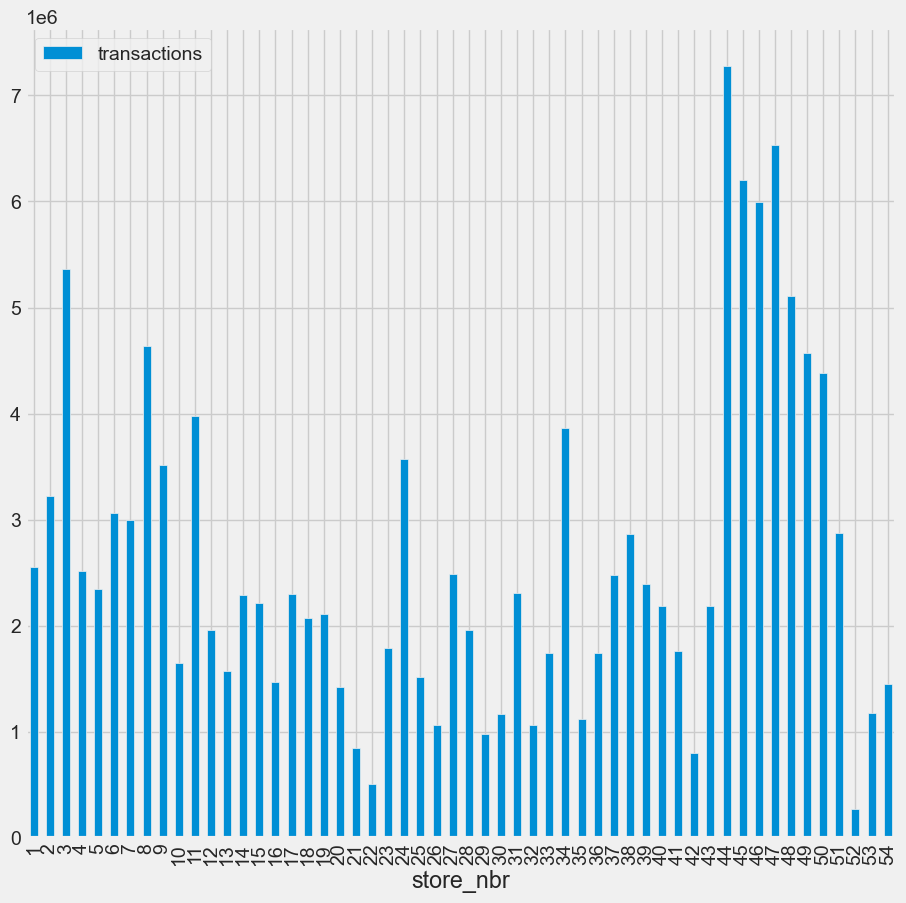

In [11]:
transactions.groupby(["store_nbr"]).agg({"transactions":"sum"}).plot.bar(figsize=(10, 10))

<Axes: ylabel='store_nbr'>

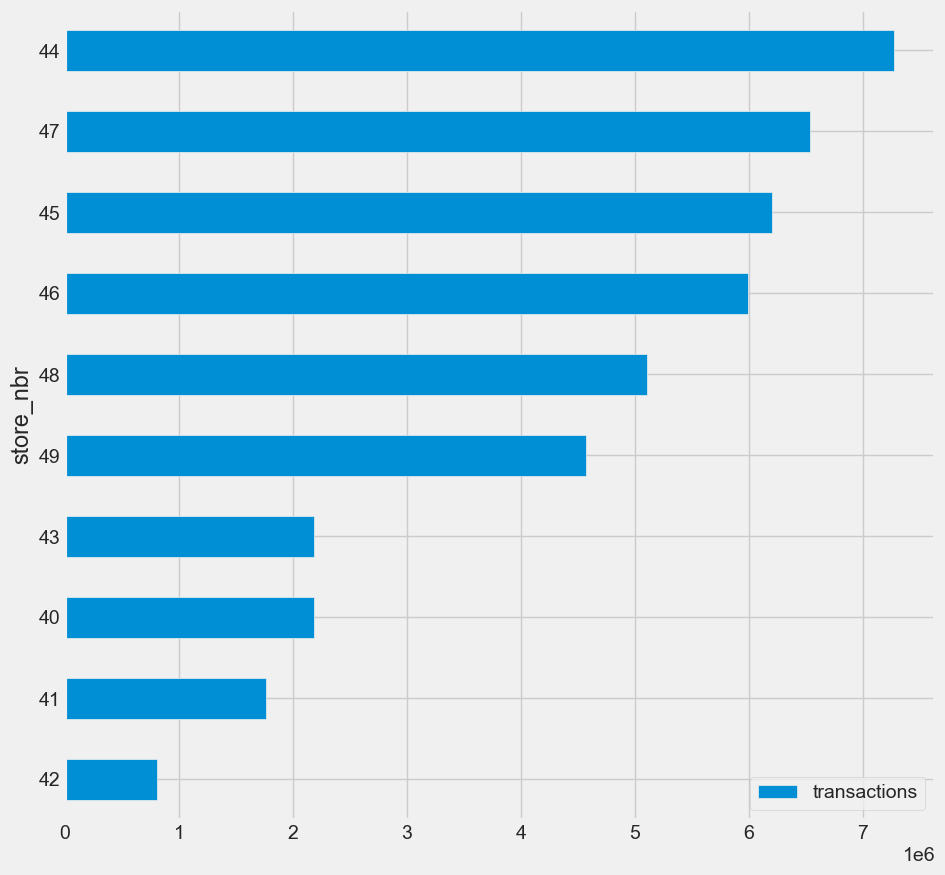

In [16]:
store_40s = list(range(40, 50))
(
    transactions
    .query("store_nbr in @store_40s")
    .groupby(["store_nbr"])
    .agg({"transactions":"sum"})
    .sort_values(by="transactions")
    .plot.barh(figsize=(10, 10))
)

In [23]:
store_40s = list(range(40, 50))
(
    transactions
    .query("store_nbr in @store_40s and date.astype('datetime64[ns]').dt.month in [1, 2, 3]")
    .pivot_table(index=transactions["date"].astype('datetime64[ns]').dt.month,
                 columns=transactions["store_nbr"],
                 values="transactions",
                 aggfunc="sum")
)

store_nbr,40,41,42,43,44,45,46,47,48,49
date,,,,,,,,,,
1,185490,148431,64758,188657,628438,538370,522763,568824,439045,386589
2,179215,143437,62400,186951,584046,511411,493100,539453,422158,362406
3,199810,156254,67713,203827,655630,561184,540294,594248,460341,407071


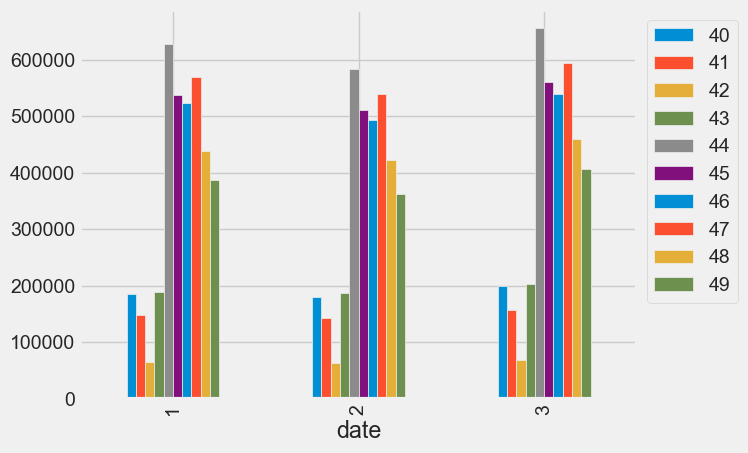

In [24]:
(
    transactions
    .query("store_nbr in @store_40s and date.astype('datetime64[ns]').dt.month in [1, 2, 3]")
    .pivot_table(index=transactions["date"].astype('datetime64[ns]').dt.month,
                 columns=transactions["store_nbr"],
                 values="transactions",
                 aggfunc="sum")
).plot.bar().legend(bbox_to_anchor=(1,1))

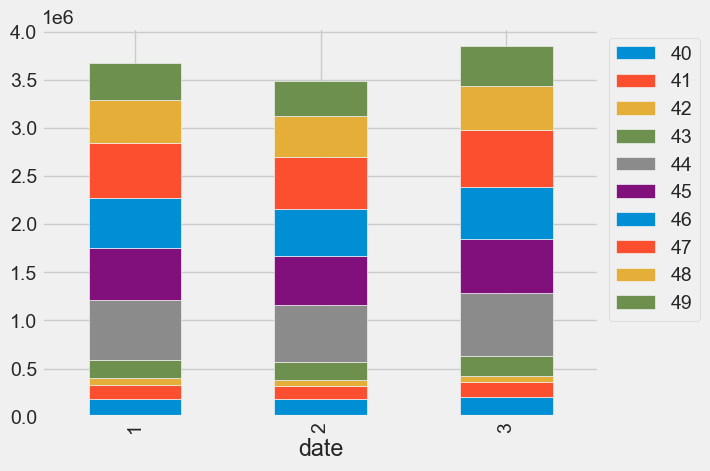

In [25]:
(
    transactions
    .query("store_nbr in @store_40s and date.astype('datetime64[ns]').dt.month in [1, 2, 3]")
    .pivot_table(index=transactions["date"].astype('datetime64[ns]').dt.month,
                 columns=transactions["store_nbr"],
                 values="transactions",
                 aggfunc="sum")
).plot.bar(stacked=True).legend(bbox_to_anchor=(1,1))

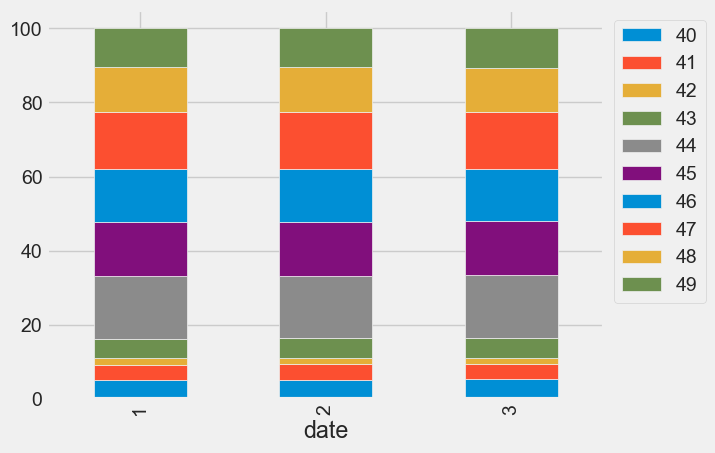

In [26]:
(
    transactions
    .query("store_nbr in @store_40s and date.astype('datetime64[ns]').dt.month in [1, 2, 3]")
    .pivot_table(index=transactions["date"].astype('datetime64[ns]').dt.month,
                 columns=transactions["store_nbr"],
                 values="transactions",
                 aggfunc="sum").apply(lambda x: x * 100 / sum(x), axis=1)
).plot.bar(stacked=True).legend(bbox_to_anchor=(1,1))